In [1]:
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y= iris.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
iris_pipeline = Pipeline([
    ('Scalar', StandardScaler()),
    ('classifier',RandomForestClassifier() )
])

In [6]:
iris_pipeline.fit(X_train, y_train)

,steps,"[('Scalar', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [7]:
y_pred  =iris_pipeline.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
print(f"Total Accuracy : {accuracy_score(y_test,y_pred)*100} %")

Total Accuracy : 100.0 %


In [10]:
print(f"\nClassification Report:")
print(classification_report(y_test,y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
cm = confusion_matrix(y_test, y_pred)

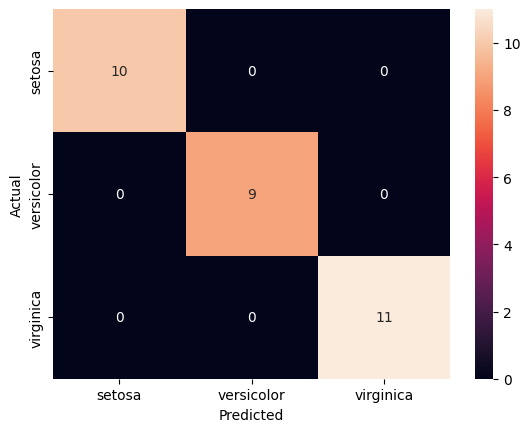

In [12]:
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.show()

In [13]:
# joblib.dump(iris_pipeline, "iris_model.pkl")
# print("model saved as iris_model.pkl")

In [14]:
vir = iris.data[iris.target == 2], iris.target[iris.target == 2]

In [15]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [16]:
df['target'] = iris.target

In [17]:
df = df[df['target'] == 2]

In [18]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2
105,7.6,3.0,6.6,2.1,2
106,4.9,2.5,4.5,1.7,2
107,7.3,2.9,6.3,1.8,2
108,6.7,2.5,5.8,1.8,2
109,7.2,3.6,6.1,2.5,2


In [19]:
stats = df.describe().loc[['min', 'max']]

In [20]:
stats

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
min,4.9,2.2,4.5,1.4,2.0
max,7.9,3.8,6.9,2.5,2.0


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|██████████| 172k/172k [00:00<00:00, 230kB/s]

Extracting files...
Path to dataset files: C:\Users\chour\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
import pandas as pd

In [5]:
import os

os.listdir(path)


['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [7]:
df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
